<a href="https://colab.research.google.com/github/Manasa23BEIS123/AIML-12-Week-Program/blob/feat%2Faiml-W3-Manasa/W3D1_Linear_Regression_Scikit_Learn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# W3D1: Linear Regression — Scikit-Learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
from sklearn.datasets import fetch_california_housing

# Load the California Housing dataset
housing = fetch_california_housing(as_frame=True)

# Create the DataFrame
df = housing.frame

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nDataset columns:")
print(df.columns.tolist())

Dataset shape: (20640, 9)

First 5 rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422



Dataset columns:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']


In [3]:
# Basic dataset exploration

print("Dataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nBasic Statistics:")
display(df.describe())

print("\nTarget Variable Statistics:")
print(df["MedHouseVal"].describe())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None

Missing Values:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Basic Statistics:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010



Target Variable Statistics:
count    20640.000000
mean         2.068558
std          1.153956
min          0.149990
25%          1.196000
50%          1.797000
75%          2.647250
max          5.000010
Name: MedHouseVal, dtype: float64


In [4]:
# Separate features and target

X = df.drop(columns=["MedHouseVal"])
y = df["MedHouseVal"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeature columns:")
print(X.columns.tolist())

print("\nFirst 5 target values:")
print(y.head())

Features shape: (20640, 8)
Target shape: (20640,)

Feature columns:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

First 5 target values:
0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64


In [5]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (16512, 8)
Testing features: (4128, 8)
Training target: (16512,)
Testing target: (4128,)


In [6]:
# Create and train the Linear Regression model

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

# Print the model coefficients
print("Intercept:", linear_model.intercept_)

print("\nCoefficients:")
for feature, coefficient in zip(X.columns, linear_model.coef_):
    print(f"{feature}: {coefficient:.6f}")

Intercept: -37.02327770606409

Coefficients:
MedInc: 0.448675
HouseAge: 0.009724
AveRooms: -0.123323
AveBedrms: 0.783145
Population: -0.000002
AveOccup: -0.003526
Latitude: -0.419792
Longitude: -0.433708


In [7]:
# Make predictions on the test set
y_pred_linear = linear_model.predict(X_test)

# Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred_linear)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_linear)
r2 = r2_score(y_test, y_pred_linear)

print("Linear Regression Performance")
print("-" * 35)
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")

Linear Regression Performance
-----------------------------------
MSE  : 0.5559
RMSE : 0.7456
MAE  : 0.5332
R²   : 0.5758


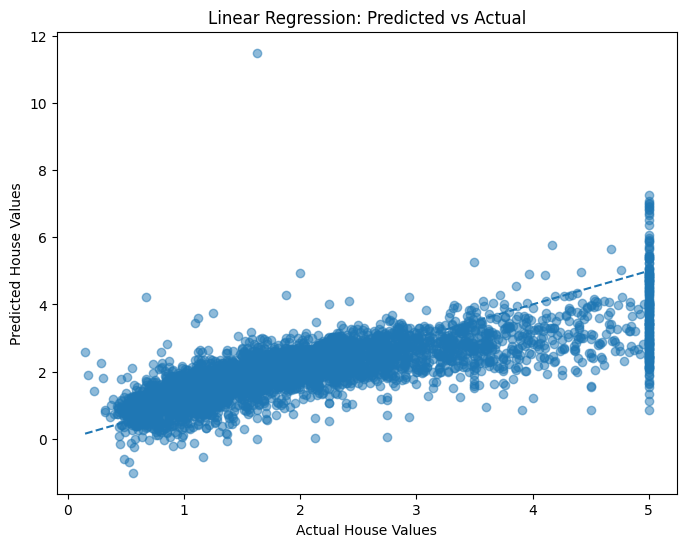

In [8]:
# Plot Predicted vs Actual values

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_linear, alpha=0.5)

# Perfect prediction reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual House Values")
plt.ylabel("Predicted House Values")
plt.title("Linear Regression: Predicted vs Actual")
plt.show()

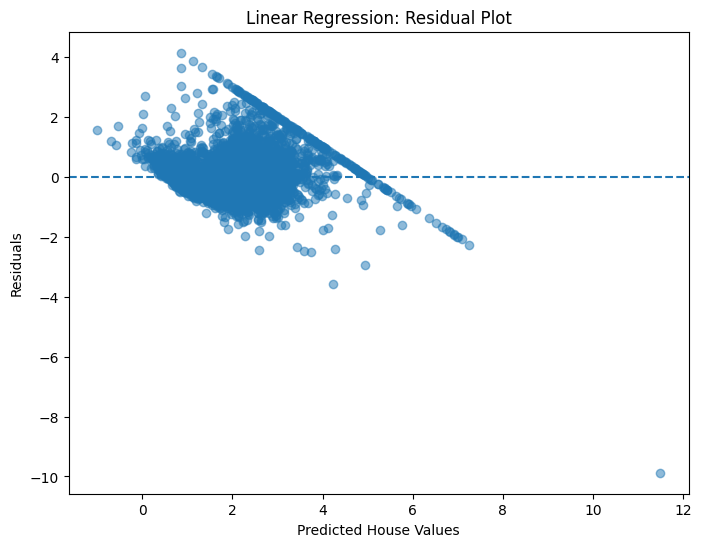

In [9]:
# Calculate residuals
residuals = y_test - y_pred_linear

# Plot residuals
plt.figure(figsize=(8, 6))

plt.scatter(y_pred_linear, residuals, alpha=0.5)

# Reference line at zero
plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted House Values")
plt.ylabel("Residuals")
plt.title("Linear Regression: Residual Plot")
plt.show()

In [10]:
# Create Ridge and Lasso models

ridge_model = Ridge(alpha=1.0)
lasso_model = Lasso(alpha=0.001)

# Train the models
ridge_model.fit(X_train, y_train)
lasso_model.fit(X_train, y_train)

# Make predictions
y_pred_ridge = ridge_model.predict(X_test)
y_pred_lasso = lasso_model.predict(X_test)

print("Ridge and Lasso models trained successfully!")

Ridge and Lasso models trained successfully!


In [11]:
# Function to calculate regression metrics
def evaluate_model(name, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return {
        "Model": name,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R²": r2
    }

# Create comparison table
results = pd.DataFrame([
    evaluate_model("Linear Regression", y_test, y_pred_linear),
    evaluate_model("Ridge Regression", y_test, y_pred_ridge),
    evaluate_model("Lasso Regression", y_test, y_pred_lasso)
])

print("Model Comparison:")
display(results.round(4))

Model Comparison:


,Model,MSE,RMSE,MAE,R²
0,Linear Regression,0.5559,0.7456,0.5332,0.5758
1,Ridge Regression,0.5558,0.7455,0.5332,0.5759
2,Lasso Regression,0.5539,0.7442,0.5333,0.5773


In [12]:
# Final validation checks

assert len(y_pred_linear) == len(y_test)
assert len(y_pred_ridge) == len(y_test)
assert len(y_pred_lasso) == len(y_test)

assert results.shape[0] == 3
assert results["MSE"].notna().all()
assert results["RMSE"].notna().all()
assert results["MAE"].notna().all()
assert results["R²"].notna().all()

print("All validation checks passed!")
print("\nFinal model comparison:")
display(results.round(4))

All validation checks passed!

Final model comparison:


,Model,MSE,RMSE,MAE,R²
0,Linear Regression,0.5559,0.7456,0.5332,0.5758
1,Ridge Regression,0.5558,0.7455,0.5332,0.5759
2,Lasso Regression,0.5539,0.7442,0.5333,0.5773


## Conclusion

The California Housing dataset was used to build and evaluate regression models.

- Trained a Linear Regression model using Scikit-Learn.
- Printed the model intercept and feature coefficients.
- Evaluated the model using MSE, RMSE, MAE, and R².
- Visualized predicted vs actual values.
- Analyzed residuals using a residual plot.
- Trained Ridge and Lasso regression models.
- Compared Linear Regression, Ridge, and Lasso using a results table.
- Performed validation checks to ensure the models and results were valid.

The models were successfully trained and compared for the house-price prediction task.